In [1]:
import boto3
import botocore
import functools
from IPython.core.display import display, HTML
from iterdub import iterdub as ib
from iterpop import iterpop as ip
import itertools as it
import json
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyanalysis import calc_loglikelihoods_by_num_sets
from dishpylib.pyanalysis import count_hands_with_k_or_more_sets
from dishpylib.pyanalysis import count_hands_without_k_or_more_sets
from dishpylib.pyanalysis import estimate_interpolation_complexity
from dishpylib.pyanalysis import calc_loglikelihoods_over_set_sizes
from dishpylib.pyhelpers import get_env_context
from dishpylib.pyhelpers import get_git_revision_hash
from dishpylib.pyhelpers import make_timestamp
from dishpylib.pyhelpers import NumpyEncoder
from dishpylib.pyhelpers import preprocess_competition_fitnesses
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmez679
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-09-12-bioticbackground-phenotype_neutral
notebook path: /home/runner/work/oee4/oee4/binder/2025-09-12-bioticbackground-phenotype_neutral.ipynb
revision: bdac574
timestamp: 2026-02-08T18:59:11Z00:00

IPython==7.16.1
packaging==26.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-09-12-bioticbackground-phenotype_neutral"


In [5]:
import boto3
import botocore
import functools
import pandas as pd

from dishpylib.pyhelpers import fit_control_t_distns

@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = [*bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions-focalbb/stage=4+what=collated/stint={stint}/',
    )][:1]

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
import functools
from iterpop import iterpop as ip
from scipy import stats


def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

dfs = []
for stint in range(101):
    print(stint)
    series_profiles, = [
    x for x in bucket_handle.objects.filter(
            Prefix=f'endeavor=16/bioticbackground-phenotype-neutral-nopout-competitions/stage=2+what=generated/stint={stint}/series=16005/a=coalescence_result',
        )
        if x.key.endswith(".csv")
    ]

    control_fits_df = get_control_t_distns('prq49', 16, stint)
    df = pd.read_csv(
        f's3://prq49/{series_profiles.key}',
    )
    df = df[df["Competition Series"] == 16005]
    df = df[df["genome morph"] != "wildtype"].copy()
    df = df[df["genome a"] == "genome"].copy()

    print(stint, len(df))
    df["Stint"] = stint
    dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
    print(dfdigest)
    df = preprocess_competition_fitnesses(df, control_fits_df)
    dfs.append(df)


0
0 1
-2d7fa14abb925f11
1
1 1
5a35f6efc70535e0
2
2 1
7f02a2058ff9e4c3
3
3 1
-592adaa92ca30744
4
4 1
-4072e666f7074fb8
5
5 1
7b1d18355bc1ea46
6
6 1
-462fbb993421d9c5
7
7 1
-1880332ca192637e
8
8 1
38a2a36eabeed526
9
9 1
290bd731594753cd
10
10 1
5d2233c268787979
11
11 1
1488336603822bb3
12
12 1
6c03990fe23d1b88
13
13 1
105be6fdb75de625
14
14 1
39c737c1a189c830
15
15 1
-7b4c3ae991923c09
16
16 1
1f42c254491116ee
17
17 1
-1fed9042cdca2a4d
18
18 1
-44af68bbdf61a089
19
19 1
44f63e19e6ad9e66
20
20 1
-74c2819868f0e91
21
21 1
1fe7cfb47e1d968
22
22 1
28d492827a89982a
23
23 1
38023a98fed84976
24
24 1
cf5851fb2ca319c
25
25 1
-11f182a437b88d1a
26
26 1
afd77a890512b19
27
27 1
51aff1b730ee65c6
28
28 1
734fef02e4198859
29
29 1
-7d1952249d60d128
30
30 1
-3e31c28b8dbec906
31
31 1
-5e18a6c488b2809d
32
32 1
694d069f146f0af2
33
33 1
-38beca1c868a58b4
34
34 1
-6ee87d04dbd197fe
35
35 1
-f84404618ae05ab
36
36 1
-4cbf528bcbf7f694
37
37 1
-7f3e3079a967c864
38
38 1
d1285b8450ffa0e
39
39 1
3e6966563ee88e16
40
40 1


In [8]:
pd.set_option('display.max_columns', None)
df = pd.concat(dfs)
df


,Competition Stint,Competition Series,Competition Replicate,Competition Treatment,Treatment _,Treatment mut_sever,Treatment mut_freq,Treatment diversity,Treatment bucket,Competition Endeavor,Competition Repro,Competition Slurm Job ID,Competition Thread,Competition Process,Update,Population Slots,Num Live Cells,Population Extinct,Num Live Cells with Focal Root ID,Focal Root ID Cells Extinct,Is Focal Root ID,Abundance,Prevalence,Focal Prevalence,Root ID,Genome Slug,Genome Filename,Fitness Differential,Fitness Differential Focal,Count,Extrospective State Target Idx,Inter Message Self-Send Filter Mod,Inter Message Self-Send Filter Target,Intermittent Extrospective State Exchange Probability,Intermittent Extrospective State Rotate Probability,Intermittent Introspective State Exchange Probability,Intermittent Introspective State Rotate Probability,Intermittent Writable State Exchange Probability,Intermittent Writable State Rotate Probability,Intra Message Self-Send Filter Mod,Intra Message Self-Send Filter Target,Introspective State Target Idx,Mutation Occurence Rate Multiplicand,Point Mutation Rate Multiplicand,Program Max Size Override,Sequence Defect Rate Multiplicand,Writable State Target Idx,genome a,genome bgpop,genome criteria,genome dose,genome ext,genome filter_except_lowest_root,genome morph,genome proc,genome root_id,genome series,genome stint,genome thread,genome variation,Stint,p,Is Less Fit,Is More Fit,Is Neutral,Relative Fitness
0,0,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,LOITpG4CJkik5yEm,61032188,0,0,13205,3600,3568,0,1429,0,1,0.204722,0.206558,0.515745,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000010,0.000001,737,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,0,0,master,0,0.080319,False,False,True,Neutral
1,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,xQ2QPpJCFToZQbz3,61033529,0,0,9513,3600,3569,0,1515,0,1,0.190000,0.191650,0.451485,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000015,-0.000005,684,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,1,0,master,1,0.369310,False,False,True,Neutral
0,2,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,W6MOF8HMW2rqLpmN,61033550,0,0,10713,3600,3564,0,1123,0,1,0.235833,0.238215,0.756011,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000009,0.000024,849,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,2,0,master,2,0.822469,False,False,True,Neutral
1,3,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,5K5B0r3rJTaMijRx,61033600,0,0,9462,3600,3595,0,1640,0,1,0.190556,0.190821,0.418293,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000015,-0.000009,686,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,3,0,master,3,0.031877,False,False,True,Neutral
0,4,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,u8ZQUENEeNZ0Zf0t,61033621,0,0,9812,3600,3583,0,1548,0,1,0.233889,0.234999,0.543928,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000010,0.000004,842,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN

<AxesSubplot:xlabel='Competition Stint', ylabel='Is More Fit'>

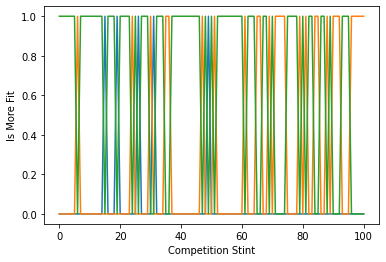

In [9]:
sns.lineplot(
    x=df["Competition Stint"],
    y=df["Is More Fit"],
)
sns.lineplot(
    x=df["Competition Stint"],
    y=df["Is Less Fit"],
)
sns.lineplot(
    x=df["Competition Stint"],
    y=df["Is Neutral"],
)


In [10]:
df[
    df["Is Less Fit"]
]


,Competition Stint,Competition Series,Competition Replicate,Competition Treatment,Treatment _,Treatment mut_sever,Treatment mut_freq,Treatment diversity,Treatment bucket,Competition Endeavor,Competition Repro,Competition Slurm Job ID,Competition Thread,Competition Process,Update,Population Slots,Num Live Cells,Population Extinct,Num Live Cells with Focal Root ID,Focal Root ID Cells Extinct,Is Focal Root ID,Abundance,Prevalence,Focal Prevalence,Root ID,Genome Slug,Genome Filename,Fitness Differential,Fitness Differential Focal,Count,Extrospective State Target Idx,Inter Message Self-Send Filter Mod,Inter Message Self-Send Filter Target,Intermittent Extrospective State Exchange Probability,Intermittent Extrospective State Rotate Probability,Intermittent Introspective State Exchange Probability,Intermittent Introspective State Rotate Probability,Intermittent Writable State Exchange Probability,Intermittent Writable State Rotate Probability,Intra Message Self-Send Filter Mod,Intra Message Self-Send Filter Target,Introspective State Target Idx,Mutation Occurence Rate Multiplicand,Point Mutation Rate Multiplicand,Program Max Size Override,Sequence Defect Rate Multiplicand,Writable State Target Idx,genome a,genome bgpop,genome criteria,genome dose,genome ext,genome filter_except_lowest_root,genome morph,genome proc,genome root_id,genome series,genome stint,genome thread,genome variation,Stint,p,Is Less Fit,Is More Fit,Is Neutral,Relative Fitness
1,6,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,kQ8ZDv0RXXR57Hu2,61033643,0,0,9476,3600,3589,0,1588,0,1,0.114444,0.114795,0.259446,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000023,-0.000025,412,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,6,0,master,6,0.003821,True,False,False,Significantly Deleterious
0,24,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,f5kDo9pfUBQbMhSs,61033882,0,0,5523,3600,3592,0,1965,0,1,0.013889,0.013920,0.025445,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000058,-0.000086,50,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,24,0,master,24,0.002395,True,False,False,Significantly Deleterious
0,30,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,IhogIcjLRuId5xsQ,61033960,0,0,4578,3600,3424,0,1380,0,1,0.015000,0.015771,0.039130,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000069,-0.000101,54,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,30,0,master,30,0.002052,True,False,False,Significantly Deleterious
0,35,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,bit5xiVa95sAC66n,61033974,0,0,832,3600,3593,0,2027,0,1,0.000000,0.000000,0.000000,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria=abundanc...,-0.000401,-0.000601,0,NaN,0,0,0,0,0,0,0,0,0,0,NaN,1,1,NaN,1,NaN,genome,1.0,abundance,NaN,.json.gz,NaN,jenga_phenotype_equivalent_nopout_with_biotic_...,0,1,16005,35,0,master,35,0.000052,True,False,False,Significantly Deleterious
0,36,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,viAZk2NPaTzoYTq6,61034056,0,0,4177,3600,3589,0,1893,0,1,0.003889,0.003901,0.007396,1,criteria%abundance~morph%jenga_phenotype_equiv...,./root_id=1+a=genome+bgpop=1+criteria